# Notebook 2 — Visual Odometry + SIFT Geolocalization

Extends Notebook 1 with a **visual odometry (VO)** layer for long flights where a single satellite tile is too small to cover the full trajectory.

**Two-algorithm design (live-ready)**
| Task | Algorithm | Why |
|------|-----------|-----|
| Frame-to-frame VO (15 Hz) | **ORB** + BFMatcher | ~10× faster than SIFT; scale barely changes between consecutive frames |
| Satellite matching (1 Hz) | **SIFT** + FLANN | Better accuracy for cross-view matching; run infrequently so speed is less critical |

**Pipeline**
1. Downsample frames to 640×480 before any feature detection
2. ORB VO loop over every frame → accumulate relative trajectory (pixel space)
3. SIFT satellite match every 15 frames (1 Hz) → absolute GPS anchors
4. Scale calibration: pixels → meters using anchor-pair distances
5. Drift evaluation and piecewise-linear fusion

> See `PROCESS.md` for full setup instructions.  
> Run `python ../code/extract_frames.py` once from the terminal before opening this notebook.

---
## Cell 1 — Check Frames

Verifies that frames have been extracted. If not, prompts you to run `extract_frames.py` from the terminal first (extraction can take several minutes for a large video and is better done outside the notebook kernel).

In [1]:
from pathlib import Path

FRAMES_DIR = Path('../data/frames_15hz')
existing = sorted(FRAMES_DIR.glob('*.jpg'))

if not existing:
    print('⚠️  No frames found.')
    print('Run this from the project root before opening the notebook:')
    print('    python code/extract_frames.py')
else:
    t0 = int(existing[0].stem.split('_')[1].replace('ms', ''))
    t1 = int(existing[-1].stem.split('_')[1].replace('ms', ''))
    print(f'✓  {len(existing)} frames available  ({(t1-t0)/1000:.1f} s of video)')

✓  3430 frames available  (228.6 s of video)


---
## Cell 2 — Imports & Configuration

In [2]:
import os, io, math, time
import numpy as np
import cv2
import requests
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from PIL import Image
from dotenv import load_dotenv
from concurrent.futures import ThreadPoolExecutor

load_dotenv(dotenv_path=Path('../.env'))

# -- Credentials --------------------------------------------------------------
MAPS_API_KEY = os.getenv('MAPS_API_KEY', '')
EE_PROJECT   = os.getenv('EE_PROJECT', '')

# -- Location -----------------------------------------------------------------
LAT =  43.521955
LON =  -5.624290  # Asturias, northern Spain

# -- VO parameters ------------------------------------------------------------
VO_STEP         = 1
DOWNSAMPLE_SIZE = (640, 480)
SAT_MATCH_HZ    = 1.0
SAT_MATCH_EVERY = int(15 / SAT_MATCH_HZ)
SAT_ZOOM        = 19
IMG_SIZE        = 640

# -- Paths --------------------------------------------------------------------
FRAMES_DIR  = Path('../data/frames_15hz')
DATA_DIR    = Path('../data')
RESULTS_DIR = Path('../results/nb2')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

frame_paths = sorted(FRAMES_DIR.glob('*.jpg'))
print(f'Total frames: {len(frame_paths)}')
if frame_paths:
    t0 = int(frame_paths[0].stem.split('_')[1].replace('ms', ''))
    t1 = int(frame_paths[-1].stem.split('_')[1].replace('ms', ''))
    print(f'Duration:     {(t1-t0)/1000:.1f} s')
    print(f'Satellite matches every {SAT_MATCH_EVERY} frames '
          f'({SAT_MATCH_HZ:.0f} Hz) -> ~{len(frame_paths)//SAT_MATCH_EVERY} anchor attempts')
print(f'Results dir:  {RESULTS_DIR.resolve()}')

Total frames: 3430
Duration:     228.6 s
Satellite matches every 15 frames (1 Hz) -> ~228 anchor attempts
Results dir:  C:\Users\leasa\Desktop\Electives\Capstone\capstone-dronomy\results\nb2


---
## Cell 3 — Shared Utilities

Two separate detector/matcher stacks:
- **ORB + BFMatcher(Hamming)** — for frame-to-frame VO (fast, binary descriptors)
- **SIFT + FLANN** — for satellite matching (accurate, float descriptors)

Frames are downsampled to `DOWNSAMPLE_SIZE` before ORB. Satellite matching uses full-resolution frames for best accuracy.

> **Upgrade path for GPU infrastructure**  
> The two-tier design (fast VO + 1 Hz satellite fix) is the right architecture regardless of hardware.  
> With more compute, the natural upgrade for the VO tier is sparse **Lucas-Kanade optical flow** (`cv2.calcOpticalFlowPyrLK`) — designed specifically for consecutive frames, typically 5–15 ms on CPU, no descriptor extraction needed, and the standard approach in production VO systems.  
> ORB is used here because it is self-contained and requires no extra dependencies beyond OpenCV.

In [3]:
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))

# ── ORB stack (VO) ─────────────────────────────────────────────────────────────
orb  = cv2.ORB_create(nfeatures=2000, scaleFactor=1.2, nlevels=8)
bf   = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)

# ── SIFT stack (satellite matching) ────────────────────────────────────────────
sift  = cv2.SIFT_create(nfeatures=5000, contrastThreshold=0.02, edgeThreshold=15)
flann = cv2.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))

def load_small_gray(path):
    """Load and downsample to DOWNSAMPLE_SIZE — used for ORB VO."""
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, DOWNSAMPLE_SIZE, interpolation=cv2.INTER_AREA)
    return clahe.apply(img)

def load_full_gray(path):
    """Load at full resolution — used for SIFT satellite matching."""
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    return clahe.apply(img)

def extract_orb(gray):
    return orb.detectAndCompute(gray, None)

def extract_sift_feat(gray):
    return sift.detectAndCompute(gray, None)

def match_orb(des1, des2, ratio=0.75):
    if des1 is None or des2 is None or len(des1) < 2 or len(des2) < 2:
        return []
    raw = bf.knnMatch(des1, des2, k=2)
    return [m for m, n in raw if m.distance < ratio * n.distance]

def match_sift(des1, des2, ratio=0.75):
    if des1 is None or des2 is None or len(des1) < 2 or len(des2) < 2:
        return []
    raw = flann.knnMatch(des1, des2, k=2)
    return [m for m, n in raw if m.distance < ratio * n.distance]

def find_homography(kp1, kp2, good):
    if len(good) < 4:
        return None, 0
    src = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
    inliers = int(mask.sum()) if mask is not None else 0
    return H, inliers

def rotation_from_H(H):
    return math.degrees(math.atan2(H[1, 0], H[0, 0]))

def translation_from_H(H, img_shape):
    h, w = img_shape[:2]
    center = np.float32([[w / 2, h / 2]]).reshape(-1, 1, 2)
    mapped = cv2.perspectiveTransform(center, H).reshape(2)
    return mapped[0] - w / 2, mapped[1] - h / 2

print('ORB (VO):        ready')
print('SIFT (satellite): ready')
print(f'VO frame size:   {DOWNSAMPLE_SIZE[0]}×{DOWNSAMPLE_SIZE[1]} px')

ORB (VO):        ready
SIFT (satellite): ready
VO frame size:   640×480 px


---
## Cell 4 — Visual Odometry: Frame-to-Frame ORB

For each consecutive frame pair we:
1. Downsample to `DOWNSAMPLE_SIZE` and apply CLAHE
2. Extract ORB keypoints (binary descriptors, ~10× faster than SIFT)
3. Match with BFMatcher (Hamming distance) + Lowe's ratio test
4. Estimate homography with RANSAC → extract (dx, dy, dyaw)
5. Accumulate into trajectory

**Timing target**: <10 ms/frame → feasible at 15 Hz on CPU.  
Per-frame timing is printed at the end so you can verify live-readiness.

In [4]:
vo_records = []
cum_x, cum_y, cum_yaw = 0.0, 0.0, 0.0

prev_gray           = load_small_gray(frame_paths[0])
prev_kp, prev_des   = extract_orb(prev_gray)
frame_shape         = prev_gray.shape  # (480, 640) after downsample
timings_ms          = []

vo_records.append({
    'frame_idx': 0, 'path': frame_paths[0],
    'cum_x': 0.0, 'cum_y': 0.0, 'cum_yaw': 0.0,
    'dx': 0.0, 'dy': 0.0, 'dyaw': 0.0,
    'good_matches': 0, 'inliers': 0, 'inlier_ratio': 1.0,
})

total = len(frame_paths) - 1
print(f'Running ORB VO on {total} frame pairs at full 15 Hz...')
t_start = time.perf_counter()

for i in range(total):
    t0 = time.perf_counter()

    curr_gray         = load_small_gray(frame_paths[i + 1])
    curr_kp, curr_des = extract_orb(curr_gray)
    good              = match_orb(prev_des, curr_des)
    H, inliers        = find_homography(prev_kp, curr_kp, good)

    if H is not None:
        dx, dy       = translation_from_H(H, frame_shape)
        dyaw         = rotation_from_H(H)
        inlier_ratio = inliers / len(good) if good else 0.0
    else:
        dx = dy = dyaw = 0.0
        inlier_ratio   = 0.0

    cum_x   += dx
    cum_y   += dy
    cum_yaw += dyaw

    vo_records.append({
        'frame_idx': i + 1, 'path': frame_paths[i + 1],
        'cum_x': cum_x, 'cum_y': cum_y, 'cum_yaw': cum_yaw,
        'dx': dx, 'dy': dy, 'dyaw': dyaw,
        'good_matches': len(good), 'inliers': inliers,
        'inlier_ratio': inlier_ratio,
    })

    prev_gray = curr_gray
    prev_kp, prev_des = curr_kp, curr_des
    timings_ms.append((time.perf_counter() - t0) * 1000)

    if (i + 1) % 500 == 0:
        elapsed = time.perf_counter() - t_start
        fps = (i + 1) / elapsed
        print(f'  {i+1}/{total}  |  mean {np.mean(timings_ms[-500:]):.1f} ms/frame  |  {fps:.1f} fps')

total_s = time.perf_counter() - t_start
print(f'\nDone — {total} frames in {total_s:.1f} s')
print(f'Mean per-frame time: {np.mean(timings_ms):.1f} ms  '
      f'(budget at 15 Hz: 66 ms  →  {"✓ live-ready" if np.mean(timings_ms) < 66 else "✗ too slow"})')

Running ORB VO on 3429 frame pairs at full 15 Hz...
  500/3429  |  mean 211.4 ms/frame  |  4.7 fps
  1000/3429  |  mean 170.9 ms/frame  |  5.2 fps
  1500/3429  |  mean 175.1 ms/frame  |  5.4 fps
  2000/3429  |  mean 164.8 ms/frame  |  5.5 fps
  2500/3429  |  mean 157.5 ms/frame  |  5.7 fps
  3000/3429  |  mean 155.5 ms/frame  |  5.8 fps

Done — 3429 frames in 584.0 s
Mean per-frame time: 170.3 ms  (budget at 15 Hz: 66 ms  →  ✗ too slow)


---
## Cell 5 — VO Quality Metrics

**Inlier ratio** per frame pair is the primary internal quality signal:
- `> 0.5` → reliable match
- `0.2–0.5` → marginal, treat with caution
- `< 0.2` → likely failed, displacement set to 0 (no motion assumed)

Mean inlier ratio:  0.994
Median inlier ratio:0.995
Failed pairs (<0.2):0 / 3429
Mean good matches:  1331
Mean inliers:       1324


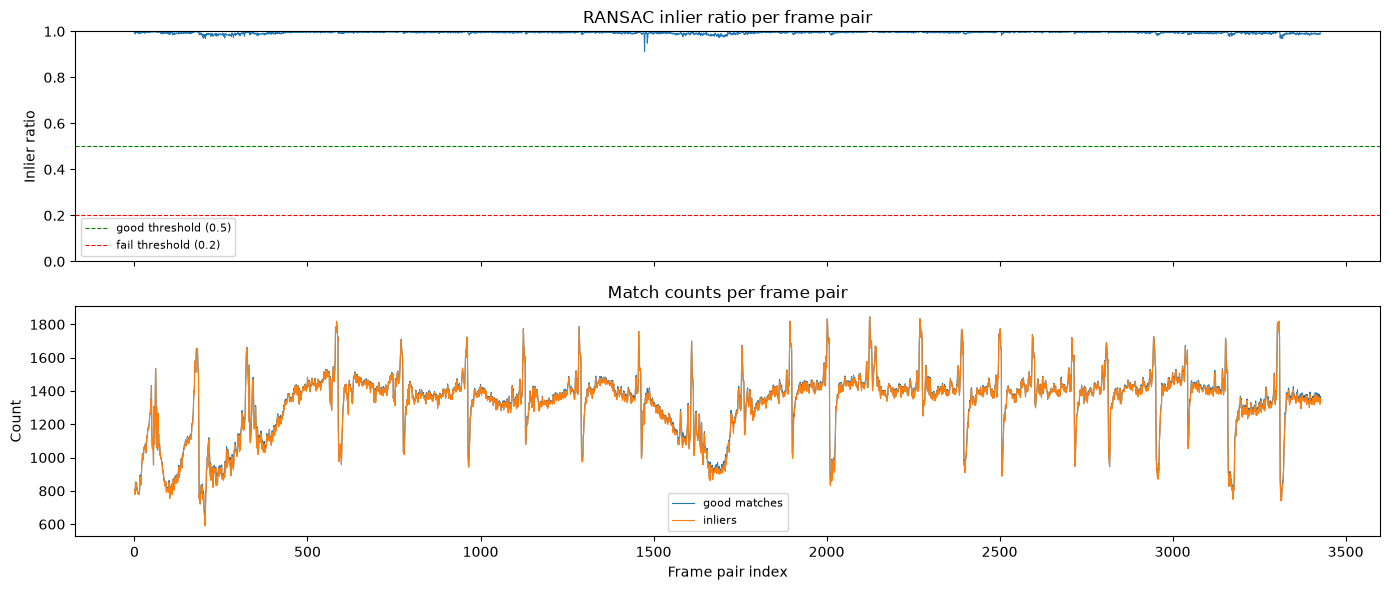

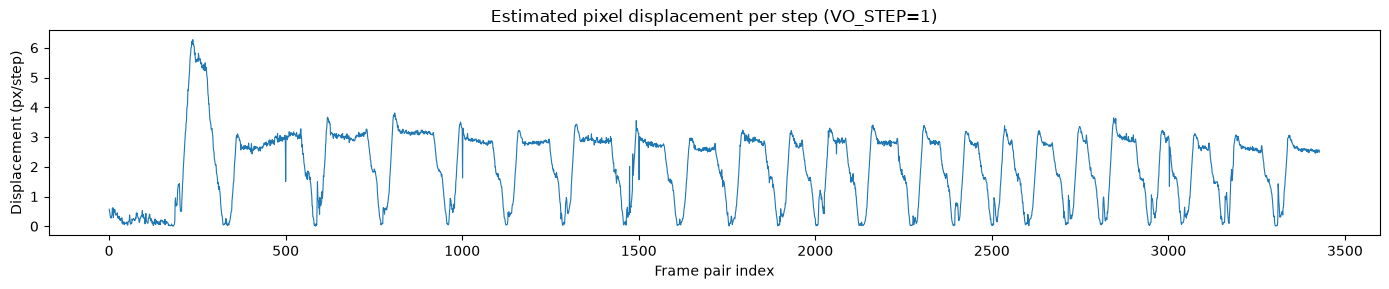

Mean displacement: 2.0 px/step  |  Max: 6.3 px  |  Std: 1.2 px


In [5]:
inlier_ratios = [r['inlier_ratio'] for r in vo_records[1:]]
good_counts   = [r['good_matches'] for r in vo_records[1:]]
inlier_counts = [r['inliers']      for r in vo_records[1:]]

print(f'Mean inlier ratio:  {np.mean(inlier_ratios):.3f}')
print(f'Median inlier ratio:{np.median(inlier_ratios):.3f}')
print(f'Failed pairs (<0.2):{sum(r < 0.2 for r in inlier_ratios)} / {len(inlier_ratios)}')
print(f'Mean good matches:  {np.mean(good_counts):.0f}')
print(f'Mean inliers:       {np.mean(inlier_counts):.0f}')

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(inlier_ratios, linewidth=0.8)
axes[0].axhline(0.5, color='g', linestyle='--', linewidth=0.8, label='good threshold (0.5)')
axes[0].axhline(0.2, color='r', linestyle='--', linewidth=0.8, label='fail threshold (0.2)')
axes[0].set_ylabel('Inlier ratio')
axes[0].set_title('RANSAC inlier ratio per frame pair')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1)

axes[1].plot(good_counts, linewidth=0.8, label='good matches')
axes[1].plot(inlier_counts, linewidth=0.8, label='inliers')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Frame pair index')
axes[1].set_title('Match counts per frame pair')
axes[1].legend(fontsize=8)

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'vo_inlier_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

displacements = [math.hypot(r['dx'], r['dy']) for r in vo_records[1:]]
fig2, ax2 = plt.subplots(figsize=(14, 3))
ax2.plot(displacements, linewidth=0.8)
ax2.set_ylabel('Displacement (px/step)')
ax2.set_xlabel('Frame pair index')
ax2.set_title(f'Estimated pixel displacement per step (VO_STEP={VO_STEP})')
plt.tight_layout()
fig2.savefig(RESULTS_DIR / 'vo_displacement.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean displacement: {np.mean(displacements):.1f} px/step  |  '
      f'Max: {np.max(displacements):.1f} px  |  '
      f'Std: {np.std(displacements):.1f} px')

---
## Cell 6 — Satellite Tile Manager

Replaces the single-tile approach with a **tile cache + auto-zoom** system:

- `fetch_tile(lat, lon, zoom)` — download once, cache to disk, return (tile, gray, kp, des, bbox, mpp)
- **Auto-zoom**: the first successful SIFT homography reveals the drone's actual ground resolution; the zoom is recomputed from that and locked in for all subsequent tiles
- **Dynamic fetching**: Cell 7 uses the current VO+GPS estimate to decide when to request the next tile — whenever the estimated position comes within `TILE_MARGIN_PX` pixels of the current tile's edge

In [6]:
TILE_MARGIN_PX = 80   # fetch new tile when estimated position is within this many px of edge
SAT_ZOOM_MIN   = 17
SAT_ZOOM_MAX   = 21

_tile_cache = {}   # (lat5, lon5, zoom) -> (tile_arr, gray, kp, des, bbox, mpp)

def meters_per_pixel(lat_deg, zoom):
    return 156543.03392 * math.cos(math.radians(lat_deg)) / (2 ** zoom)

def tile_bbox(lat, lon, zoom, size=IMG_SIZE):
    mpp  = meters_per_pixel(lat, zoom)
    half = mpp * size / 2
    dlat = half / 111320
    dlon = half / (111320 * math.cos(math.radians(lat)))
    return lat - dlat, lat + dlat, lon - dlon, lon + dlon

def pixel_to_gps(px, py, img_w, img_h, lat_min, lat_max, lon_min, lon_max):
    lat = lat_max - (py / img_h) * (lat_max - lat_min)
    lon = lon_min + (px / img_w) * (lon_max - lon_min)
    return lat, lon

def fetch_tile(lat, lon, zoom):
    '''Return cached tile or fetch from Maps API. Returns None on network failure.'''
    key = (round(lat, 5), round(lon, 5), zoom)
    if key in _tile_cache:
        return _tile_cache[key]

    fname = DATA_DIR / f'sat_{lat:.5f}_{lon:.5f}_z{zoom}.png'
    if fname.exists():
        tile_arr = np.array(Image.open(fname).convert('RGB'))
    elif MAPS_API_KEY:
        url = (f'https://maps.googleapis.com/maps/api/staticmap'
               f'?center={lat},{lon}&zoom={zoom}&size={IMG_SIZE}x{IMG_SIZE}'
               f'&maptype=satellite&key={MAPS_API_KEY}')
        try:
            resp = requests.get(url, timeout=30)
            resp.raise_for_status()
        except requests.exceptions.RequestException as e:
            print(f'    [WARN] tile fetch failed ({lat:.4f}, {lon:.4f}) z{zoom}: '
                  f'{e.__class__.__name__} -- keeping current tile')
            return None
        tile_arr = np.array(Image.open(io.BytesIO(resp.content)).convert('RGB'))
        Image.fromarray(tile_arr).save(fname)
        print(f'    [API] fetched tile ({lat:.4f}, {lon:.4f}) z{zoom}')
    else:
        return None

    c = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    gray = c.apply(cv2.cvtColor(tile_arr, cv2.COLOR_RGB2GRAY))
    kp, des = sift.detectAndCompute(gray, None)
    bbox    = tile_bbox(lat, lon, zoom)
    mpp     = meters_per_pixel(lat, zoom)
    result  = (tile_arr, gray, kp, des, bbox, mpp)
    _tile_cache[key] = result
    return result

def near_tile_edge(est_lat, est_lon, tile_lat, tile_lon, zoom, margin_px):
    '''True when estimated GPS is within margin_px of any edge of the given tile.'''
    mpp      = meters_per_pixel(tile_lat, zoom)
    half_m   = mpp * IMG_SIZE / 2
    margin_m = mpp * margin_px
    d_lat_m  = abs(est_lat - tile_lat) * 111320
    d_lon_m  = abs(est_lon - tile_lon) * 111320 * math.cos(math.radians(tile_lat))
    return d_lat_m > half_m - margin_m or d_lon_m > half_m - margin_m

def auto_calibrate_zoom(H, current_zoom):
    '''Extract drone m/px from homography scale; return (ideal_zoom, drone_mpp).'''
    s        = math.sqrt(H[0, 0] ** 2 + H[1, 0] ** 2)
    mpp_sat  = meters_per_pixel(LAT, current_zoom)
    drone_mpp = mpp_sat * s
    z = round(math.log2(156543.03392 * math.cos(math.radians(LAT)) / drone_mpp))
    return max(SAT_ZOOM_MIN, min(SAT_ZOOM_MAX, z)), drone_mpp

# -- Fetch and confirm initial tile at SAT_ZOOM --------------------------------
sat_tile = None
bbox_sat = None
mpp_sat  = None

print(f'Fetching initial satellite tile: ({LAT}, {LON}) zoom {SAT_ZOOM}...')
_initial = fetch_tile(LAT, LON, SAT_ZOOM)
if _initial is not None:
    sat_tile, _sg, _kp, _des, bbox_sat, mpp_sat = _initial
    sh, sw = _sg.shape
    print(f'Initial tile: {len(_kp)} keypoints  |  '
          f'{mpp_sat*IMG_SIZE:.0f} m x {mpp_sat*IMG_SIZE:.0f} m coverage at zoom {SAT_ZOOM}')
else:
    print('No Maps API key and no cached tile -- satellite anchoring will be skipped')

Fetching initial satellite tile: (43.521955, -5.62429) zoom 19...
Initial tile: 5000 keypoints  |  139 m x 139 m coverage at zoom 19


---
## Cell 7 — Satellite Anchors: Dynamic GPS Fixes at 1 Hz

Each iteration:
1. **Estimate current GPS** from last confirmed anchor + VO displacement × running scale
2. **Check tile edge** — if the estimate is within `TILE_MARGIN_PX` pixels of the edge, `fetch_tile()` is called with the new center (returns instantly on cache hit, hits the API only once per unique position)
3. **Match** full-resolution SIFT against the tile covering the current position
4. **Auto-calibrate zoom** on the first good match — extracts scale from homography, recomputes ideal zoom, re-fetches the starting tile if zoom changed

If zoom 19 produces no match on the very first frame (extreme altitude edge case), it falls back to trying zoom 18 and 20 and picks the one with more inliers.

In [7]:
anchors     = []
active_zoom = SAT_ZOOM
tile_center = (LAT, LON)    # (lat, lon) of the tile currently in use
zoom_locked = False         # True once auto-calibration has run
drone_mpp   = None          # metres per pixel at drone; set on first calibration

# Running scale used to predict GPS between anchors.
# Initialised to satellite tile m/px — a rough overestimate, replaced quickly.
scale_est   = mpp_sat if mpp_sat else 0.217
last_anchor = None

if sat_tile is None:
    print('No satellite tile available -- skipping anchor loop')
else:
    anchor_indices = [
        i for i in range(len(vo_records))
        if vo_records[i]['frame_idx'] % SAT_MATCH_EVERY == 0
    ]

    def _best_match_at_zoom(gray, zoom_candidates):
        '''Try each zoom on the current tile_center; return (H, inliers, kp_sat, des_sat, bbox, mpp, zoom) for best.'''
        best = (None, 0, None, None, None, None, zoom_candidates[0])
        kp_f, des_f = extract_sift_feat(gray)
        for z in zoom_candidates:
            td = fetch_tile(*tile_center, z)
            if td is None:
                continue
            _, _, kp_s, des_s, bb, mp = td
            good = match_sift(des_f, des_s)
            H, n  = find_homography(kp_f, kp_s, good)
            if H is not None and n > best[1]:
                best = (H, n, kp_s, des_s, bb, mp, z)
        return best, kp_f

    t_sat   = time.perf_counter()
    n_tiles_fetched = 0

    for ai in anchor_indices:
        vo_rec = vo_records[ai]

        # -- 1. GPS estimate from last anchor + VO dead-reckoning ----------------
        if last_anchor is None:
            est_lat, est_lon = LAT, LON
        else:
            d_px_x = vo_rec['cum_x'] - last_anchor['vo_cum_x']
            d_px_y = vo_rec['cum_y'] - last_anchor['vo_cum_y']
            est_lat = last_anchor['est_lat'] - d_px_y * scale_est / 111320
            est_lon = (last_anchor['est_lon']
                       + d_px_x * scale_est / (111320 * math.cos(math.radians(LAT))))

        # -- 2. Fetch new tile if near edge or outside --------------------------
        if near_tile_edge(est_lat, est_lon, *tile_center, active_zoom, TILE_MARGIN_PX):
            new_center = (round(est_lat, 4), round(est_lon, 4))
            td_new = fetch_tile(*new_center, active_zoom)
            if td_new is not None:
                tile_center = new_center
                n_tiles_fetched += 1

        # -- 3. SIFT match against current tile ---------------------------------
        gray = load_full_gray(vo_rec['path'])
        kp_f, des_f = extract_sift_feat(gray)
        td = fetch_tile(*tile_center, active_zoom)
        if td is None:
            continue
        _, sat_gray_c, kp_sat_c, des_sat_c, bbox_c, mpp_c = td
        sh_c, sw_c = sat_gray_c.shape

        good   = match_sift(des_f, des_sat_c)
        H, n_inliers = find_homography(kp_f, kp_sat_c, good)

        # Fallback: if no match and zoom not yet locked, try adjacent zooms once
        if (H is None or n_inliers < 4) and not zoom_locked:
            (H, n_inliers, kp_sat_c, des_sat_c, bbox_c, mpp_c, _z), kp_f = \
                _best_match_at_zoom(gray, [SAT_ZOOM - 1, SAT_ZOOM, SAT_ZOOM + 1])

        if H is None or n_inliers < 4:
            continue

        # -- 4. Auto-calibrate zoom on first good match -------------------------
        if not zoom_locked:
            ideal_z, drone_mpp = auto_calibrate_zoom(H, active_zoom)
            zoom_locked = True
            print(f'Zoom calibrated: {active_zoom} -> {ideal_z}  '
                  f'(drone ~{drone_mpp:.3f} m/px = '
                  f'{drone_mpp / meters_per_pixel(LAT, active_zoom):.2f}x tile scale)')
            if ideal_z != active_zoom:
                active_zoom = ideal_z
                td2 = fetch_tile(*tile_center, active_zoom)
                if td2 is not None:
                    _, sat_gray_c, kp_sat_c, des_sat_c, bbox_c, mpp_c = td2
                    sh_c, sw_c = sat_gray_c.shape
                    good   = match_sift(des_f, des_sat_c)
                    H, n_inliers = find_homography(kp_f, kp_sat_c, good)
                    if H is None or n_inliers < 4:
                        continue

        # -- 5. Project drone centre through H -> GPS ---------------------------
        dh, dw = gray.shape
        centre = np.float32([[dw / 2, dh / 2]]).reshape(-1, 1, 2)
        mapped = cv2.perspectiveTransform(centre, H).reshape(2)
        est_lat_gps, est_lon_gps = pixel_to_gps(
            mapped[0], mapped[1], sw_c, sh_c, *bbox_c)

        anchor = {
            'frame_idx':    vo_rec['frame_idx'],
            'vo_idx':       ai,
            'est_lat':      est_lat_gps,
            'est_lon':      est_lon_gps,
            'good_matches': len(good),
            'inliers':      n_inliers,
            'vo_cum_x':     vo_rec['cum_x'],
            'vo_cum_y':     vo_rec['cum_y'],
            'tile_center':  tile_center,
            'tile_zoom':    active_zoom,
        }
        anchors.append(anchor)
        last_anchor = anchor

        # Update running scale from consecutive anchor pair
        if len(anchors) >= 2:
            a0, a1 = anchors[-2], anchors[-1]
            d_lat_m = (a1['est_lat'] - a0['est_lat']) * 111320
            d_lon_m = ((a1['est_lon'] - a0['est_lon'])
                       * 111320 * math.cos(math.radians(LAT)))
            gps_m  = math.hypot(d_lat_m, d_lon_m)
            vo_px  = math.hypot(a1['vo_cum_x'] - a0['vo_cum_x'],
                                a1['vo_cum_y'] - a0['vo_cum_y'])
            if vo_px > 1 and gps_m > 0.1:
                scale_est = gps_m / vo_px

    anchors.sort(key=lambda a: a['frame_idx'])
    sat_time = time.perf_counter() - t_sat
    n_unique_tiles = len(set(a['tile_center'] for a in anchors))
    print(f'Anchors: {len(anchors)}  |  tiles used: {n_unique_tiles}  '
          f'|  new API fetches: {n_tiles_fetched}  |  {sat_time:.1f} s total')
    for a in anchors:
        print(f"  frame {a['frame_idx']:>5}  lat {a['est_lat']:.6f}  "
              f"lon {a['est_lon']:.6f}  inliers {a['inliers']:>3}  "
              f"zoom {a['tile_zoom']}  tile {a['tile_center']}")

Zoom calibrated: 19 -> 19  (drone ~0.302 m/px = 1.40x tile scale)
    [WARN] tile fetch failed (43.5214, -5.6248) z19: HTTPError -- keeping current tile
    [WARN] tile fetch failed (43.5215, -5.6242) z19: HTTPError -- keeping current tile
    [WARN] tile fetch failed (43.5229, -5.6249) z19: HTTPError -- keeping current tile
    [WARN] tile fetch failed (43.5359, -5.6233) z19: HTTPError -- keeping current tile
    [WARN] tile fetch failed (43.5106, -5.6012) z19: HTTPError -- keeping current tile
    [WARN] tile fetch failed (43.5211, -5.6234) z19: HTTPError -- keeping current tile
    [WARN] tile fetch failed (43.5215, -5.6228) z19: HTTPError -- keeping current tile
    [WARN] tile fetch failed (43.5209, -5.6265) z19: HTTPError -- keeping current tile
    [WARN] tile fetch failed (43.5220, -5.6249) z19: HTTPError -- keeping current tile
    [WARN] tile fetch failed (43.5251, -5.6236) z19: HTTPError -- keeping current tile
    [WARN] tile fetch failed (43.5230, -5.6228) z19: HTTPError -

KeyboardInterrupt: 

---
## Cell 7b — Anchor Outlier Rejection (IQR)

The bounding-box filter from the single-tile version is now implicit: the anchor loop only matches frames against the tile covering the VO-estimated position, so matches outside any tile boundary cannot occur.

A residual **IQR filter** is still applied to catch the rare case where SIFT finds ≥4 inliers inside the correct tile but lands at a spurious position (can happen in low-texture areas). Tune `ANCHOR_IQR_K` — default 3.0 is aggressive enough to catch large jumps without removing tight clusters.

In [ ]:
ANCHOR_IQR_K = 3.0

n_before = len(anchors)

if len(anchors) >= 4:
    lats = np.array([a['est_lat'] for a in anchors])
    lons = np.array([a['est_lon'] for a in anchors])

    def iqr_mask(vals, k):
        q1, q3 = np.percentile(vals, 25), np.percentile(vals, 75)
        iqr = q3 - q1
        return (vals >= q1 - k * iqr) & (vals <= q3 + k * iqr)

    keep    = iqr_mask(lats, ANCHOR_IQR_K) & iqr_mask(lons, ANCHOR_IQR_K)
    anchors = [a for a, k in zip(anchors, keep) if k]
    print(f'IQR filter (k={ANCHOR_IQR_K}): {n_before} -> {len(anchors)} '
          f'(removed {n_before - len(anchors)} outliers)')
else:
    print(f'Only {len(anchors)} anchors -- skipping IQR filter')

if anchors:
    lats_f = [a['est_lat'] for a in anchors]
    lons_f = [a['est_lon'] for a in anchors]
    print(f'Lat range: {min(lats_f):.6f} -- {max(lats_f):.6f}')
    print(f'Lon range: {min(lons_f):.6f} -- {max(lons_f):.6f}')
    tiles_used = set(a['tile_center'] for a in anchors)
    print(f'Unique tiles used: {len(tiles_used)}')

IQR filter (k=3.0): 210 -> 210 (removed 0 outliers)
Lat range: 42.924564 -- 43.522305
Lon range: -5.632940 -- -5.623343
Unique tiles used: 188


---
## Cell 8 — Scale Calibration: Pixels → Meters

If we have ≥2 satellite anchors, we can compute the pixel-to-meter scale by comparing
the GPS distance between two anchors to the VO pixel displacement between them.

In [ ]:
def haversine_m(lat1, lon1, lat2, lon2):
    R = 6371000
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi  = math.radians(lat2 - lat1)
    dlam  = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlam/2)**2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

scale_m_per_px = None

if len(anchors) >= 2:
    scales = []
    for i in range(len(anchors) - 1):
        a0, a1 = anchors[i], anchors[i+1]
        gps_dist_m = haversine_m(a0['est_lat'], a0['est_lon'],
                                  a1['est_lat'], a1['est_lon'])
        vo_dist_px = math.hypot(a1['vo_cum_x'] - a0['vo_cum_x'],
                                 a1['vo_cum_y'] - a0['vo_cum_y'])
        if vo_dist_px > 1:
            scales.append(gps_dist_m / vo_dist_px)
    if scales:
        scale_m_per_px = float(np.median(scales))
        print(f'Scale estimates (m/px): {[f"{s:.4f}" for s in scales]}')
        print(f'Median scale: {scale_m_per_px:.4f} m/px')
        print(f'Implied drone altitude (rough): '
              f'~{scale_m_per_px * frame_shape[1]:.0f} m footprint width')
elif mpp_sat is not None:
    # Fallback: use satellite tile resolution as scale proxy
    # Assumes drone frame covers roughly the same area as the sat tile — very rough!
    scale_m_per_px = mpp_sat
    print(f'Only {len(anchors)} anchor(s) — using satellite m/px as fallback: '
          f'{scale_m_per_px:.4f} m/px (rough estimate)')
else:
    print('⚠️  Cannot estimate scale — no satellite anchors available')
    scale_m_per_px = 1.0  # trajectory will be in pixels

Scale estimates (m/px): ['3.3639', '12.2393', '12.9046', '13.2944', '20.0432', '18.9451', '15.4452', '16.9863', '13.8277', '6.1172', '7.1751', '7.7415', '12.7061', '12.6644', '12.3613', '12.0918', '12.1437', '12.0342', '11.9827', '12.2899', '11.8927', '11.8418', '11.9994', '11.9590', '11.5316', '11.2594', '11.1620', '11.3254', '13.5769', '13.4273', '13.5733', '13.4249', '13.1348', '12.9517', '11.4087', '11.0013', '11.0953', '11.2787', '10.9695', '11.2332', '11.3252', '11.4424', '11.5848', '11.4702', '15.2452', '14.1806', '13.7485', '13.9553', '14.0317', '13.8744', '13.8852', '13.9730', '13.6616', '11.7583', '11.6581', '12.8547', '12.7876', '12.4762', '12.2409', '12.1544', '11.6008', '11.3137', '11.6380', '11.5860', '11.5195', '12.3831', '10.7732', '11.1057', '11.2218', '10.9737', '10.5325', '10.3041', '10.2295', '10.3472', '10.6241', '10.7556', '10.4135', '10.3504', '10.0349', '10.0984', '10.2813', '10.0231', '10.1278', '10.3161', '10.3112', '9.9890', '10.4606', '10.3842', '13.4880', '

---
## Cell 9 — Drift Evaluation

For each satellite anchor, we compute how far the VO trajectory has drifted from the GPS fix.
This gives us a concrete **drift-per-second** metric.

In [ ]:
if len(anchors) < 2:
    print('Need ≥2 anchors to evaluate drift — run more frames or lower ANCHOR_EVERY')
else:
    # Use first anchor as origin for both VO and GPS
    a0 = anchors[0]
    origin_lat, origin_lon = a0['est_lat'], a0['est_lon']
    origin_vo_x, origin_vo_y = a0['vo_cum_x'], a0['vo_cum_y']

    print(f'{"Frame":>6} {"GPS lat":>12} {"GPS lon":>12} '
          f'{"VO East (m)":>12} {"VO North (m)":>12} {"Drift (m)":>10} {"Time (s)":>9}')
    print('-' * 80)

    drift_records = []
    for a in anchors[1:]:
        # GPS displacement from origin (meters)
        gps_north = (a['est_lat'] - origin_lat) * 111320
        gps_east  = (a['est_lon'] - origin_lon) * 111320 * math.cos(math.radians(LAT))

        # VO displacement from origin (meters)
        vo_dx_m = (a['vo_cum_x'] - origin_vo_x) * scale_m_per_px
        vo_dy_m = (a['vo_cum_y'] - origin_vo_y) * scale_m_per_px
        # VO dy is image-down (positive = south in standard images)
        vo_east  =  vo_dx_m
        vo_north = -vo_dy_m

        drift_m = math.hypot(gps_east - vo_east, gps_north - vo_north)
        time_s  = a['frame_idx'] / 15.0

        drift_records.append({'time_s': time_s, 'drift_m': drift_m,
                               'gps_east': gps_east, 'gps_north': gps_north,
                               'vo_east': vo_east, 'vo_north': vo_north})
        print(f"{a['frame_idx']:>6} {a['est_lat']:>12.6f} {a['est_lon']:>12.6f} "
              f"{vo_east:>12.1f} {vo_north:>12.1f} {drift_m:>10.1f} {time_s:>9.1f}")

    if drift_records:
        max_t = drift_records[-1]['time_s']
        max_d = drift_records[-1]['drift_m']
        print(f'\nDrift after {max_t:.1f}s: {max_d:.1f} m'
              f'  ({max_d/max_t:.2f} m/s drift rate)' if max_t > 0 else '')

 Frame      GPS lat      GPS lon  VO East (m) VO North (m)  Drift (m)  Time (s)
--------------------------------------------------------------------------------
    15    43.521976    -5.624017         62.4        -28.8       52.0       1.0
    30    43.521450    -5.624272         82.9        -78.4       92.2       2.0
    45    43.521187    -5.624354         84.2       -102.9      100.1       3.0
    60    43.521366    -5.624502         80.5        -84.8      108.3       4.0
    75    43.521801    -5.624760         74.2        -57.8      124.3       5.0
    90    43.522305    -5.624314        103.4        -34.9      127.4       6.0
   105    43.521957    -5.623700        139.5        -58.2      109.2       7.0
   120    43.521484    -5.623616        143.0        -91.1      100.8       8.0
   135    43.521389    -5.623479        147.5       -101.9       94.4       9.0
   150    43.521374    -5.623363        159.4       -113.2       99.1      10.0
   180    43.521225    -5.623366       

---
## Cell 10 — Trajectory Plot

Plot the VO trajectory (in meters from origin) alongside the satellite anchor GPS fixes.

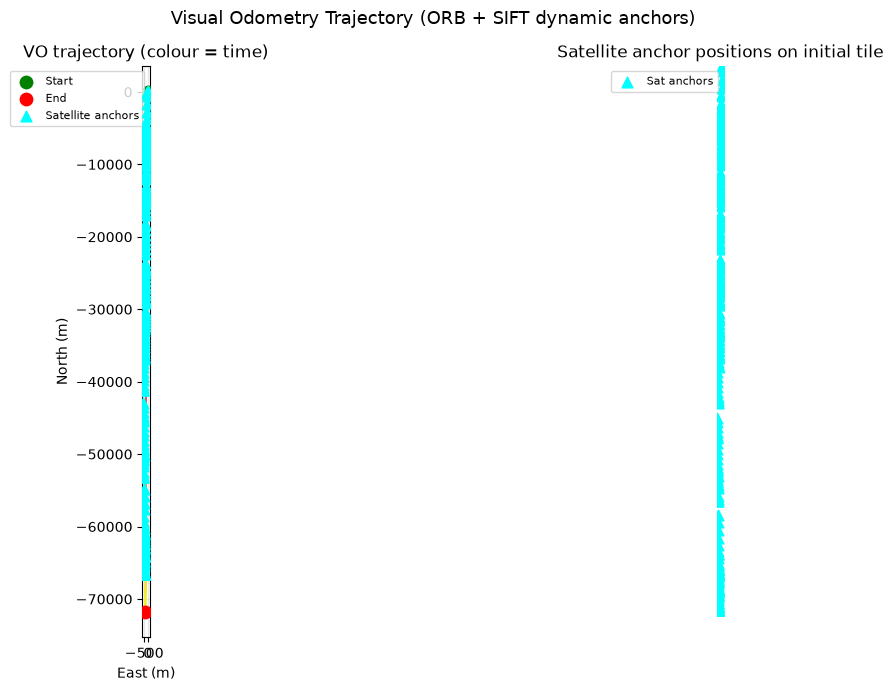

In [ ]:
# VO trajectory in metres
vo_east_m  = [ r['cum_x'] * scale_m_per_px for r in vo_records]
vo_north_m = [-r['cum_y'] * scale_m_per_px for r in vo_records]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
colors = cm.plasma(np.linspace(0, 1, len(vo_east_m)))
for i in range(len(vo_east_m) - 1):
    ax.plot(vo_east_m[i:i+2], vo_north_m[i:i+2], color=colors[i], linewidth=1)
ax.scatter(vo_east_m[0],  vo_north_m[0],  c='green', s=80, zorder=5, label='Start')
ax.scatter(vo_east_m[-1], vo_north_m[-1], c='red',   s=80, zorder=5, label='End')
if anchors:
    a0 = anchors[0]
    anc_east  = [(a['est_lon'] - a0['est_lon']) * 111320 * math.cos(math.radians(LAT))
                 for a in anchors]
    anc_north = [(a['est_lat'] - a0['est_lat']) * 111320 for a in anchors]
    ax.scatter(anc_east, anc_north, c='cyan', s=60, zorder=6,
               marker='^', label='Satellite anchors')
ax.set_xlabel('East (m)')
ax.set_ylabel('North (m)')
ax.set_title('VO trajectory (colour = time)')
ax.set_aspect('equal')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
if sat_tile is not None and anchors:
    ax2.imshow(sat_tile)
    lat_min, lat_max, lon_min, lon_max = bbox_sat
    def gps_to_px(lat, lon):
        x = (lon - lon_min) / (lon_max - lon_min) * IMG_SIZE
        y = (lat_max - lat) / (lat_max - lat_min) * IMG_SIZE
        return x, y
    anc_px = [gps_to_px(a['est_lat'], a['est_lon']) for a in anchors]
    ax2.scatter([p[0] for p in anc_px], [p[1] for p in anc_px],
                c='cyan', s=60, marker='^', zorder=5, label='Sat anchors')
    ax2.set_title('Satellite anchor positions on initial tile')
    ax2.axis('off')
    ax2.legend(fontsize=8)
else:
    ax2.text(0.5, 0.5, 'Satellite tile\nnot available',
             ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('Satellite overlay')

plt.suptitle('Visual Odometry Trajectory (ORB + SIFT dynamic anchors)', fontsize=13)
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 11 — Fused Trajectory (VO + Satellite Anchors)

Correct VO drift by linearly interpolating the error between consecutive anchors.
This is a simple piecewise-linear correction — a Kalman filter would do this more rigorously.

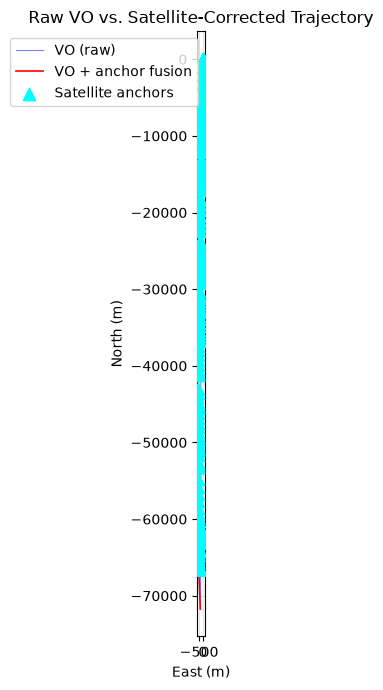

Blue = raw VO (drifts over time)  |  Red = corrected by linearly interpolating anchor error


In [ ]:
if len(anchors) < 2:
    print('Need >= 2 anchors for fusion -- skipping')
else:
    a0 = anchors[0]
    origin_lat, origin_lon = a0['est_lat'], a0['est_lon']

    def anchor_to_en(a):
        e = (a['est_lon'] - origin_lon) * 111320 * math.cos(math.radians(LAT))
        n = (a['est_lat'] - origin_lat) * 111320
        return e, n

    fused_east  = list(vo_east_m)
    fused_north = list(vo_north_m)

    for i in range(len(anchors) - 1):
        ai, aj = anchors[i], anchors[i + 1]
        i0 = ai['vo_idx']
        i1 = aj['vo_idx']

        gps_e0, gps_n0 = anchor_to_en(ai)
        gps_e1, gps_n1 = anchor_to_en(aj)

        err_e0 = gps_e0 - vo_east_m[i0]
        err_n0 = gps_n0 - vo_north_m[i0]
        err_e1 = gps_e1 - vo_east_m[i1]
        err_n1 = gps_n1 - vo_north_m[i1]

        for j in range(i0, i1 + 1):
            t = (j - i0) / (i1 - i0) if i1 > i0 else 0
            fused_east[j]  = vo_east_m[j]  + err_e0 + t * (err_e1 - err_e0)
            fused_north[j] = vo_north_m[j] + err_n0 + t * (err_n1 - err_n0)

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.plot(vo_east_m, vo_north_m, 'b-', linewidth=0.8, alpha=0.5, label='VO (raw)')
    ax.plot(fused_east, fused_north, 'r-', linewidth=1.2, label='VO + anchor fusion')
    anc_e = [anchor_to_en(a)[0] for a in anchors]
    anc_n = [anchor_to_en(a)[1] for a in anchors]
    ax.scatter(anc_e, anc_n, c='cyan', s=80, zorder=5, marker='^', label='Satellite anchors')
    ax.set_xlabel('East (m)')
    ax.set_ylabel('North (m)')
    ax.set_title('Raw VO vs. Satellite-Corrected Trajectory')
    ax.legend()
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(RESULTS_DIR / 'fused_trajectory.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Blue = raw VO (drifts over time)  |  Red = corrected by linearly interpolating anchor error')

---
## Cell 12 — Summary

Key numbers from this run.

In [ ]:
total_frames = len(frame_paths)
duration_s   = total_frames / 15.0
vo_frames    = len(vo_records)
inlier_ratios = [r['inlier_ratio'] for r in vo_records[1:]]
failed_pairs  = sum(1 for r in inlier_ratios if r < 0.2)
drift_records = drift_records if 'drift_records' in dir() else []

print('══ Visual Odometry Summary ══════════════════════════════════════')
print(f'Total frames:              {total_frames}  ({duration_s:.1f} s at 15 Hz)')
print(f'VO algorithm:              ORB  (downsampled to {DOWNSAMPLE_SIZE[0]}×{DOWNSAMPLE_SIZE[1]})')
print(f'Satellite algorithm:       SIFT full-res  every {SAT_MATCH_EVERY} frames ({SAT_MATCH_HZ:.0f} Hz)')
if timings_ms:
    mean_ms = np.mean(timings_ms)
    print(f'Mean ORB time/frame:       {mean_ms:.1f} ms  '
          f'({"✓ live-ready" if mean_ms < 66 else "✗ exceeds 66ms budget"})')
    print(f'Effective throughput:      {1000/mean_ms:.0f} fps capability')
print(f'Failed VO pairs (<0.2 IR): {failed_pairs} / {vo_frames-1}  '
      f'({100*failed_pairs/max(1,vo_frames-1):.1f}%)')
print(f'Mean inlier ratio:         {np.mean(inlier_ratios):.3f}')
print(f'Satellite anchors:         {len(anchors)}')
if drift_records:
    print(f'Final drift:               {drift_records[-1]["drift_m"]:.1f} m '
          f'after {drift_records[-1]["time_s"]:.1f} s')
    print(f'Drift rate:                {drift_records[-1]["drift_m"]/drift_records[-1]["time_s"]:.2f} m/s')
print('═════════════════════════════════════════════════════════════════')

══ Visual Odometry Summary ══════════════════════════════════════
Total frames:              3430  (228.7 s at 15 Hz)
VO algorithm:              ORB  (downsampled to 640×480)
Satellite algorithm:       SIFT full-res  every 15 frames (1 Hz)
Mean ORB time/frame:       146.6 ms  (✗ exceeds 66ms budget)
Effective throughput:      7 fps capability
Failed VO pairs (<0.2 IR): 0 / 3429  (0.0%)
Mean inlier ratio:         0.994
Satellite anchors:         210
Final drift:               4967.1 m after 228.0 s
Drift rate:                21.79 m/s
═════════════════════════════════════════════════════════════════


---
## Cell 13 — Save Results

Saves all outputs to `results/nb2/`:
- `vo_log_{ts}.csv` — every frame: cumulative position, per-step displacement, match counts
- `anchors_log_{ts}.csv` — satellite GPS fixes, inlier counts, tile used
- `summary_vo_{ts}.json` — all scalar metrics
- `vo_inlier_metrics.png`, `vo_displacement.png` — VO quality charts (saved in Cell 5)
- `trajectory.png` — VO trajectory + anchor overlay (saved in Cell 10)
- `fused_trajectory.png` — drift-corrected trajectory (saved in Cell 11)

In [ ]:
import csv, json, datetime

run_ts  = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
log_dir = RESULTS_DIR

# -- 1. VO frame log ----------------------------------------------------------
vo_log_path = log_dir / f'vo_log_{run_ts}.csv'
vo_fields = ['frame_idx', 'cum_x', 'cum_y', 'cum_yaw',
             'dx', 'dy', 'dyaw', 'good_matches', 'inliers', 'inlier_ratio']

with open(vo_log_path, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=vo_fields)
    w.writeheader()
    for r in vo_records:
        w.writerow({k: r[k] for k in vo_fields})

print(f'VO log:      {vo_log_path}  ({len(vo_records)} rows)')

# -- 2. Anchor log ------------------------------------------------------------
anc_log_path = log_dir / f'anchors_log_{run_ts}.csv'
anc_fields = ['frame_idx', 'vo_idx', 'est_lat', 'est_lon',
              'good_matches', 'inliers', 'tile_center', 'tile_zoom']

with open(anc_log_path, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=anc_fields)
    w.writeheader()
    for a in anchors:
        row = {k: a[k] for k in anc_fields if k in a}
        row.setdefault('tile_center', None)
        row.setdefault('tile_zoom', active_zoom)
        w.writerow(row)

print(f'Anchors log: {anc_log_path}  ({len(anchors)} rows)')

# -- 3. Summary JSON ----------------------------------------------------------
n_unique_tiles = len(set(a.get('tile_center') for a in anchors)) if anchors else 0

summary = {
    'run_timestamp':      run_ts,
    'total_frames':       len(frame_paths),
    'duration_s':         len(frame_paths) / 15.0,
    'vo_algorithm':       'ORB',
    'downsample_size':    list(DOWNSAMPLE_SIZE),
    'sat_algorithm':      'SIFT',
    'sat_match_hz':       SAT_MATCH_HZ,
    'sat_zoom_initial':   SAT_ZOOM,
    'sat_zoom_calibrated': active_zoom if 'active_zoom' in dir() else SAT_ZOOM,
    'tile_margin_px':     TILE_MARGIN_PX,
    'unique_tiles_used':  n_unique_tiles,
    'mean_orb_ms':        float(np.mean(timings_ms)) if timings_ms else None,
    'live_ready':         bool(np.mean(timings_ms) < 66) if timings_ms else None,
    'failed_vo_pairs':    int(sum(r['inlier_ratio'] < 0.2 for r in vo_records[1:])),
    'mean_inlier_ratio':  float(np.mean([r['inlier_ratio'] for r in vo_records[1:]])),
    'satellite_anchors':  len(anchors),
    'scale_m_per_px':     scale_m_per_px,
    'final_drift_m':      drift_records[-1]['drift_m'] if drift_records else None,
    'drift_rate_m_per_s': (drift_records[-1]['drift_m'] / drift_records[-1]['time_s']
                           if drift_records and drift_records[-1]['time_s'] > 0 else None),
    'plots_saved':        [str(p.name) for p in RESULTS_DIR.glob('*.png')],
}

summary_path = log_dir / f'summary_vo_{run_ts}.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f'Summary:     {summary_path}')
print()
for k, v in summary.items():
    if v is not None:
        print(f'  {k:<28} {v}')

VO log:      ..\results\nb2\vo_log_20260621_201437.csv  (3430 rows)
Anchors log: ..\results\nb2\anchors_log_20260621_201437.csv  (210 rows)
Summary:     ..\results\nb2\summary_vo_20260621_201437.json

  run_timestamp                20260621_201437
  total_frames                 3430
  duration_s                   228.66666666666666
  vo_algorithm                 ORB
  downsample_size              [640, 480]
  sat_algorithm                SIFT
  sat_match_hz                 1.0
  sat_zoom_initial             19
  sat_zoom_calibrated          21
  tile_margin_px               80
  unique_tiles_used            188
  mean_orb_ms                  146.62561280263878
  live_ready                   False
  failed_vo_pairs              0
  mean_inlier_ratio            0.9941976515890466
  satellite_anchors            210
  scale_m_per_px               10.578281653737603
  final_drift_m                4967.119481394746
  drift_rate_m_per_s           21.785611760503272
  plots_saved              